In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("arista_synthetic_telemetry_data.csv", parse_dates=["timestamp"])

# 1. Basic completeness
print("=== Null Audit ===")
null_report = pd.DataFrame({
    "null_count"  : df.isnull().sum(),
    "null_pct"    : df.isnull().mean().mul(100).round(2),
    "dtype"       : df.dtypes
})
print(null_report)

# 2. Duplicate events (same device + timestamp + event_type)
dupes = df.duplicated(subset=["timestamp","device","event_type"])
print(f"\nDuplicate rows: {dupes.sum()}")

# 3. Timestamp monotonicity per device
df = df.sort_values(["device","timestamp"])
df["prev_ts"] = df.groupby("device")["timestamp"].shift(1)
df["ts_delta_sec"] = (df["timestamp"] - df["prev_ts"]).dt.total_seconds()
negative_deltas = (df["ts_delta_sec"] < 0).sum()
print(f"Negative time deltas (out-of-order events): {negative_deltas}")

# 4. Value range sanity — packet_loss should be 0-100%
print("\n=== Value ranges per event type ===")
print(df.groupby("event_type")["value"].describe().round(2))

=== Null Audit ===
             null_count  null_pct           dtype
timestamp             0      0.00  datetime64[ns]
source_type           0      0.00          object
device                0      0.00          object
event_type            0      0.00          object
severity              0      0.00          object
message               0      0.00          object
value              7525     73.41         float64

Duplicate rows: 0
Negative time deltas (out-of-order events): 0

=== Value ranges per event type ===
                 count    mean     std   min    25%    50%    75%    max
event_type                                                              
account_lock       0.0     NaN     NaN   NaN    NaN    NaN    NaN    NaN
acl_add            0.0     NaN     NaN   NaN    NaN    NaN    NaN    NaN
bandwidth_spike  473.0  516.28  285.33  12.0  278.0  527.0  756.0  998.0
config_change      0.0     NaN     NaN   NaN    NaN    NaN    NaN    NaN
cpu_high         478.0   48.44   29.30   

=== Kruskal-Wallis test: value ~ event_type ===
H=1000.41, p=2.9113e-215
→ Event types ARE statistically separable by value

=== Pairwise Mann-Whitney U tests ===
  login_failure or login_success has no numeric values — skip
  packet_loss or interface_up has no numeric values — skip
  cpu_high             vs memory_high          → NOT SEPARABLE (p=0.8546)
  account_lock or login_failure has no numeric values — skip


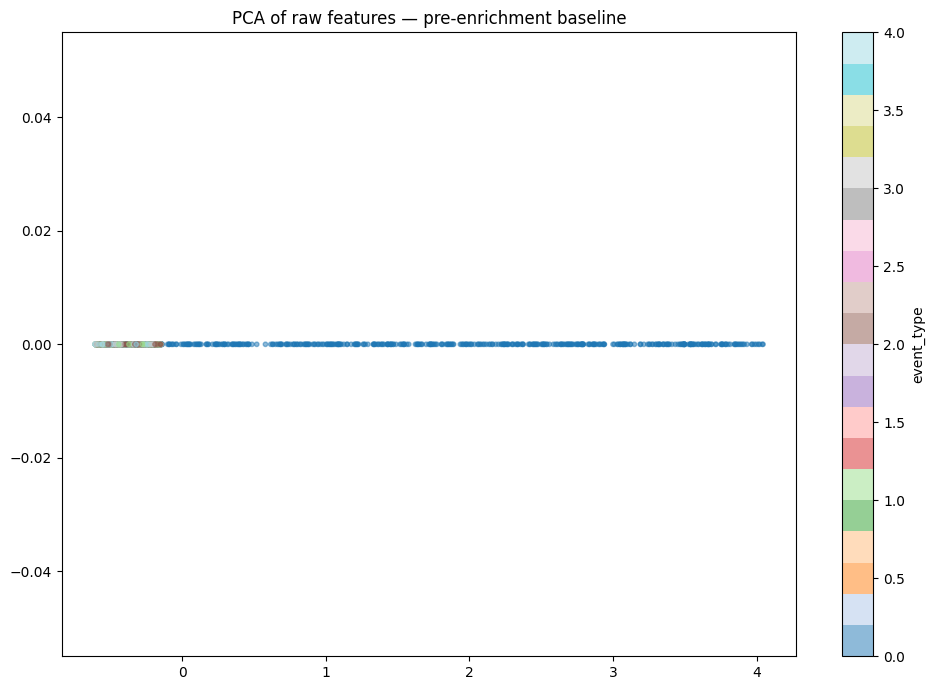

In [3]:
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from itertools import combinations

# ── Test 1: Do event types have statistically different value distributions?
print("=== Kruskal-Wallis test: value ~ event_type ===")
groups = [g["value"].dropna().values
          for _, g in df.groupby("event_type")
          if g["value"].notna().sum() > 10]
stat, p = stats.kruskal(*groups)
print(f"H={stat:.2f}, p={p:.4e}")
print("→ Event types ARE statistically separable by value" if p < 0.05
      else "→ WARNING: Event types are NOT separable by value alone")

# ── Test 2: Pairwise separation between the most important event pairs
critical_pairs = [
    ("login_failure", "login_success"),
    ("packet_loss",   "interface_up"),
    ("cpu_high",      "memory_high"),
    ("account_lock",  "login_failure"),
]
print("\n=== Pairwise Mann-Whitney U tests ===")
for e1, e2 in critical_pairs:
    v1 = df[df["event_type"]==e1]["value"].dropna()
    v2 = df[df["event_type"]==e2]["value"].dropna()
    if len(v1) > 5 and len(v2) > 5:
        stat, p = stats.mannwhitneyu(v1, v2, alternative="two-sided")
        sep = "SEPARABLE" if p < 0.05 else "NOT SEPARABLE"
        print(f"  {e1:20s} vs {e2:20s} → {sep} (p={p:.4f})")
    else:
        print(f"  {e1} or {e2} has no numeric values — skip")

# ── Test 3: PCA separability score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Use only rows where value is not null for this test
df_num = df[df["value"].notna()].copy()
le = LabelEncoder()
df_num["event_id"] = le.fit_transform(df_num["event_type"])

features = ["value"]   # expand this after feature engineering
X = StandardScaler().fit_transform(df_num[features])
pca = PCA(n_components=1) # Changed n_components from 2 to 1
coords = pca.fit_transform(X)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(coords[:,0], [0] * len(coords), # Only one component, plot against a constant y
                     c=df_num["event_id"], cmap="tab20", alpha=0.5, s=10)
plt.colorbar(scatter, ax=ax, label="event_type")
ax.set_title("PCA of raw features — pre-enrichment baseline")
plt.tight_layout(); plt.show()

PC1 explains: 13.5%
PC2 explains: 11.5%
Combined    : 25.0%


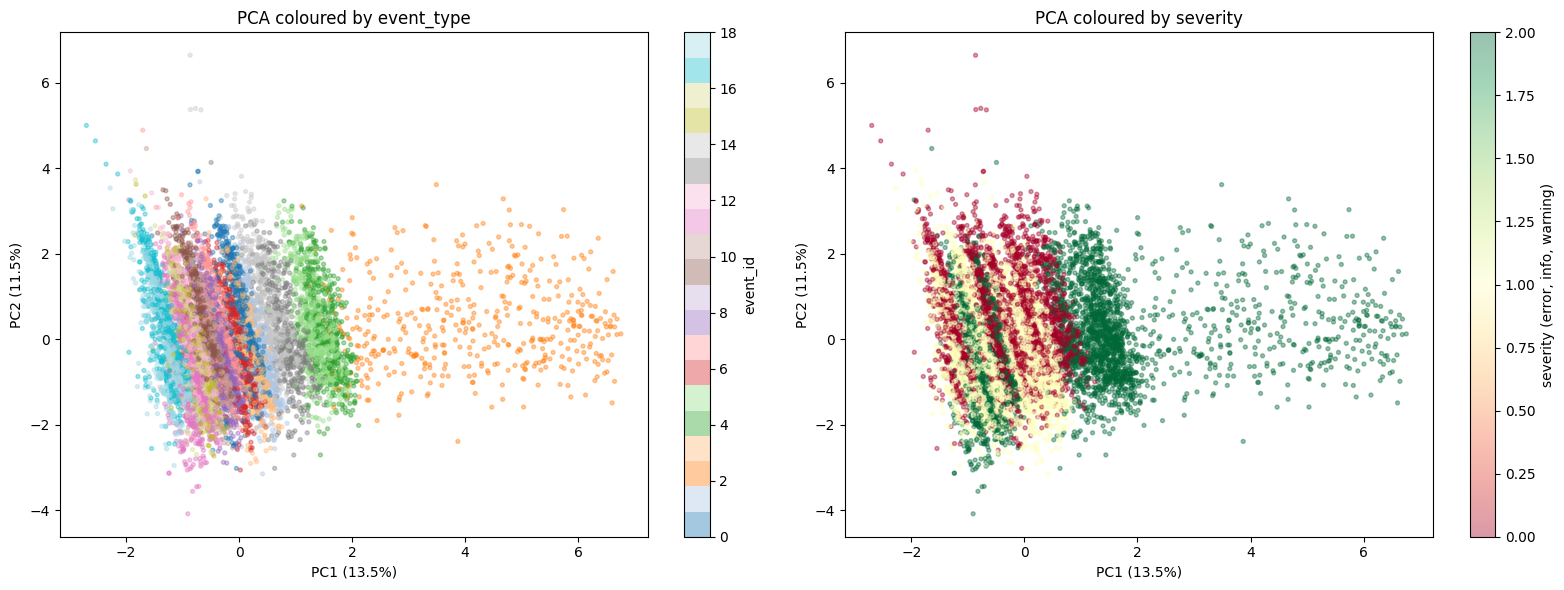

In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv("arista_synthetic_telemetry_data.csv", parse_dates=["timestamp"])
df = df.sort_values(["device","timestamp"]).reset_index(drop=True)

le_event = LabelEncoder()
df["event_id"] = le_event.fit_transform(df["event_type"])
le_dev   = LabelEncoder()
df["device_id"] = le_dev.fit_transform(df["device"])
le_src   = LabelEncoder()
df["source_id"] = le_src.fit_transform(df["source_type"])

# ── Build enriched features before PCA ────────────────────────────────────────
df["value_observed"]    = df["value"].notna().astype(int)
df["value"]             = df.groupby("event_type")["value"] \
                            .transform(lambda x: x.fillna(x.mean())).fillna(0)
df["time_delta_sec"]    = df.groupby("device")["timestamp"] \
                            .diff().dt.total_seconds().fillna(0)
df["hour_of_day"]       = df["timestamp"].dt.hour
df["day_of_week"]       = df["timestamp"].dt.dayofweek
df["prev_was_error"]    = (df.groupby("device")["severity"]
                            .shift(1).fillna("info") == "error").astype(int)
df["rolling_error_rate"]= df.groupby("device")["severity"] \
                            .transform(lambda x:
                                (x=="error").rolling(10,min_periods=1).mean())
df["login_fail_streak"] = df.groupby("device")["event_type"] \
                            .transform(lambda x:
                                (x=="login_failure").rolling(5,min_periods=1).sum())
df["events_1h"]         = df.groupby("device")["event_id"] \
                            .transform(lambda x: x.rolling(20,min_periods=1).count())

FEATURE_COLS = [
    "event_id", "device_id", "source_id", "value", "value_observed",
    "time_delta_sec", "hour_of_day", "day_of_week",
    "prev_was_error", "rolling_error_rate", "login_fail_streak", "events_1h"
]

X  = StandardScaler().fit_transform(df[FEATURE_COLS])
pca = PCA(n_components=2)
coords = pca.fit_transform(X)

print(f"PC1 explains: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2 explains: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Combined    : {pca.explained_variance_ratio_.sum()*100:.1f}%")

# ── Plot 1: coloured by event_type ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(coords[:,0], coords[:,1],
                     c=df["event_id"], cmap="tab20",
                     alpha=0.4, s=8)
axes[0].set_title("PCA coloured by event_type")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.colorbar(sc, ax=axes[0], label="event_id")

# ── Plot 2: coloured by severity ──────────────────────────────────────────────
le_sev = LabelEncoder()
sev_ids = le_sev.fit_transform(df["severity"])
sc2 = axes[1].scatter(coords[:,0], coords[:,1],
                      c=sev_ids,
                      cmap="RdYlGn", alpha=0.4, s=8)
axes[1].set_title("PCA coloured by severity")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.colorbar(sc2, ax=axes[1],
             label=f"severity ({', '.join(le_sev.classes_)})")

plt.tight_layout()
plt.show()

In [6]:
# Identify what's in the far-right outlier cluster
df["pc1"] = coords[:, 0]
df["pc2"] = coords[:, 1]

outliers = df[df["pc1"] > 4].copy()
print(f"Outlier count: {len(outliers)}")
print("\nEvent type breakdown:")
print(outliers["event_type"].value_counts())
print("\nSeverity breakdown:")
print(outliers["severity"].value_counts())
print("\nDevice breakdown:")
print(outliers["device"].value_counts())
print("\nFeature means vs full dataset means:")
feat_compare = pd.DataFrame({
    "outliers" : outliers[FEATURE_COLS].mean(),
    "full_data": df[FEATURE_COLS].mean()
})
feat_compare["ratio"] = feat_compare["outliers"] / feat_compare["full_data"].replace(0, np.nan)
print(feat_compare.round(3))

Outlier count: 248

Event type breakdown:
event_type
bandwidth_spike    248
Name: count, dtype: int64

Severity breakdown:
severity
warning    248
Name: count, dtype: int64

Device breakdown:
device
switch2    41
switch1    36
serverB    34
app1       32
serverA    28
db1        27
router2    25
router1    25
Name: count, dtype: int64

Feature means vs full dataset means:
                    outliers  full_data   ratio
event_id               2.000      9.233   0.217
device_id              3.778      3.475   1.087
source_id              1.000      1.298   0.771
value                749.851     34.693  21.614
value_observed         1.000      0.266   3.761
time_delta_sec      2277.593   2020.132   1.127
hour_of_day           12.121     11.465   1.057
day_of_week            3.069      2.978   1.030
prev_was_error         0.214      0.304   0.703
rolling_error_rate     0.261      0.305   0.856
login_fail_streak      0.282      0.337   0.836
events_1h             19.907     19.852   1.003


In [7]:
# Replace global StandardScaler on value with per-event-type z-score
df["value_zscore_local"] = df.groupby("event_type")["value"] \
    .transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))

# Keep the global-scaled value too — it carries cross-event-type magnitude info
# Now you have both:
# value_zscore_local  → is this value unusual FOR THIS event type?
# value (global)      → raw magnitude signal

print("Local z-score stats per event type:")
print(df.groupby("event_type")["value_zscore_local"].describe().round(3))

Local z-score stats per event type:
                 count  mean  std    min    25%    50%    75%    max
event_type                                                          
account_lock     678.0   0.0  0.0  0.000  0.000  0.000  0.000  0.000
acl_add          413.0   0.0  0.0  0.000  0.000  0.000  0.000  0.000
bandwidth_spike  473.0   0.0  1.0 -1.767 -0.835  0.038  0.840  1.688
config_change    431.0   0.0  0.0  0.000  0.000  0.000  0.000  0.000
cpu_high         478.0  -0.0  1.0 -1.619 -0.834 -0.015  0.906  1.726
disk_alert       617.0   0.0  1.0 -1.783 -0.834  0.009  0.852  1.661
firmware_update  441.0   0.0  0.0  0.000  0.000  0.000  0.000  0.000
interface_down   484.0   0.0  0.0  0.000  0.000  0.000  0.000  0.000
interface_up     493.0   0.0  0.0  0.000  0.000  0.000  0.000  0.000
kernel_panic     625.0   0.0  0.0  0.000  0.000  0.000  0.000  0.000
link_flap        528.0   0.0  0.0  0.000  0.000  0.000  0.000  0.000
login_failure    692.0   0.0  0.0  0.000  0.000  0.000  0.000  0.00

In [8]:
# Flag values that are unusual relative to their own event type's distribution
df["value_local_anomaly"] = (
    df["value_zscore_local"].abs() > 2.0
).astype(int)

print("\nValue anomaly rate per event type:")
print(df.groupby("event_type")["value_local_anomaly"]
        .mean().mul(100).round(2).sort_values(ascending=False))


Value anomaly rate per event type:
event_type
account_lock       0.0
acl_add            0.0
bandwidth_spike    0.0
config_change      0.0
cpu_high           0.0
disk_alert         0.0
firmware_update    0.0
interface_down     0.0
interface_up       0.0
kernel_panic       0.0
link_flap          0.0
login_failure      0.0
login_success      0.0
memory_high        0.0
packet_loss        0.0
policy_update      0.0
rollback           0.0
service_error      0.0
service_restart    0.0
Name: value_local_anomaly, dtype: float64


In [9]:
# Was there a config_change on the same device in the last 30 minutes?
df["ts_unix"] = df["timestamp"].astype(np.int64) // 10**9

def recent_event_count(group, target_event, window_sec=1800):
    """Count occurrences of target_event in preceding window_sec seconds."""
    counts = []
    times  = group["ts_unix"].values
    events = group["event_type"].values
    for i in range(len(times)):
        mask = (times >= times[i] - window_sec) & (times < times[i])
        counts.append((events[mask] == target_event).sum())
    return counts

results = []
for dev, grp in df.sort_values("timestamp").groupby("device"):
    grp = grp.copy()
    grp["prior_config_change"] = recent_event_count(grp, "config_change")
    grp["prior_acl_add"]       = recent_event_count(grp, "acl_add")
    grp["prior_policy_update"] = recent_event_count(grp, "policy_update")
    results.append(grp)

df = pd.concat(results).sort_values("timestamp").reset_index(drop=True)

# For bandwidth_spike events specifically, check if these are elevated
bw = df[df["event_type"] == "bandwidth_spike"]
print("\nBandwidth spike context (mean preceding events in 30min window):")
print(bw[["prior_config_change","prior_acl_add","prior_policy_update"]].mean().round(3))
print("\nFull dataset baseline:")
print(df[["prior_config_change","prior_acl_add","prior_policy_update"]].mean().round(3))


Bandwidth spike context (mean preceding events in 30min window):
prior_config_change    0.095
prior_acl_add          0.053
prior_policy_update    0.032
dtype: float64

Full dataset baseline:
prior_config_change    0.048
prior_acl_add          0.035
prior_policy_update    0.035
dtype: float64


In [10]:
FEATURE_COLS_V2 = [
    # Original
    "event_id", "device_id", "source_id",
    "value",                        # global magnitude
    "value_zscore_local",           # deviation within event type  ← new
    "value_local_anomaly",          # binary flag                  ← new
    "value_observed",
    "time_delta_sec",
    "hour_of_day", "day_of_week",
    "prev_was_error",
    "rolling_error_rate",
    "login_fail_streak",
    "events_1h",
    # Causal context                                                ← new
    "prior_config_change",
    "prior_acl_add",
    "prior_policy_update",
]

PC1 explains: 13.5%
PC2 explains: 11.5%
Combined    : 25.0%


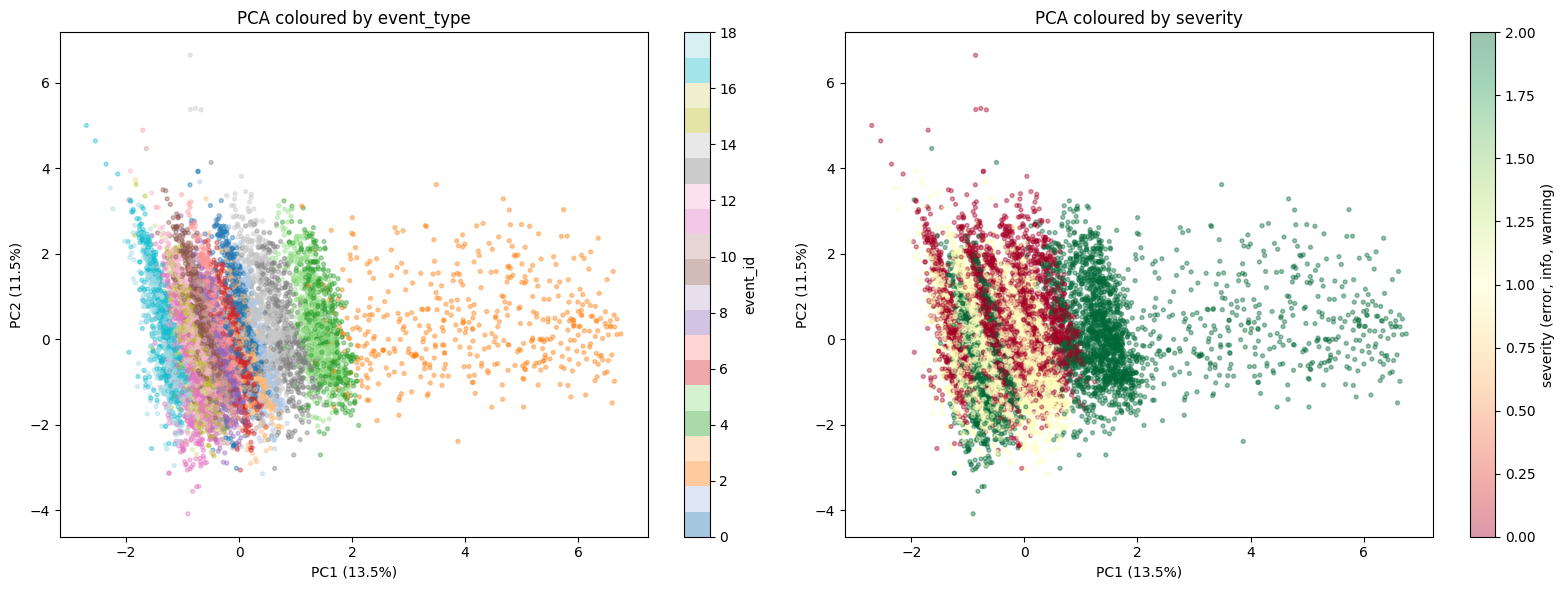

In [11]:
X  = StandardScaler().fit_transform(df[FEATURE_COLS])
pca = PCA(n_components=2)
coords = pca.fit_transform(X)

print(f"PC1 explains: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2 explains: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Combined    : {pca.explained_variance_ratio_.sum()*100:.1f}%")

# ── Plot 1: coloured by event_type ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(coords[:,0], coords[:,1],
                     c=df["event_id"], cmap="tab20",
                     alpha=0.4, s=8)
axes[0].set_title("PCA coloured by event_type")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.colorbar(sc, ax=axes[0], label="event_id")

# ── Plot 2: coloured by severity ──────────────────────────────────────────────
le_sev = LabelEncoder()
sev_ids = le_sev.fit_transform(df["severity"])
sc2 = axes[1].scatter(coords[:,0], coords[:,1],
                      c=sev_ids,
                      cmap="RdYlGn", alpha=0.4, s=8)
axes[1].set_title("PCA coloured by severity")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.colorbar(sc2, ax=axes[1],
             label=f"severity ({', '.join(le_sev.classes_)})")

plt.tight_layout()
plt.show()

In [12]:
print("Features actually used in PCA:")
print(FEATURE_COLS_V2)
print(f"\nShape of X matrix: {X.shape}")
# Should show (10250, 17) if all new features were included
# If it shows (10250, 12) the old feature list was used

Features actually used in PCA:
['event_id', 'device_id', 'source_id', 'value', 'value_zscore_local', 'value_local_anomaly', 'value_observed', 'time_delta_sec', 'hour_of_day', 'day_of_week', 'prev_was_error', 'rolling_error_rate', 'login_fail_streak', 'events_1h', 'prior_config_change', 'prior_acl_add', 'prior_policy_update']

Shape of X matrix: (10250, 12)


In [15]:
# Did the synthetic generator encode any causality at all?
df_sorted = df.sort_values(["device","timestamp"])

print("=== Causality Check ===\n")

# 1. Does bandwidth_spike follow config events more than baseline?
bw_spikes = df[df["event_type"] == "bandwidth_spike"]
print(f"bandwidth_spike — mean prior_config_change : {bw_spikes['prior_config_change'].mean():.4f}")
print(f"Full dataset    — mean prior_config_change : {df['prior_config_change'].mean():.4f}")
print()

# 2. Does account_lock follow login_failure more than baseline?
acct_lock = df[df["event_type"] == "account_lock"]
print(f"account_lock — mean login_fail_streak : {acct_lock['login_fail_streak'].mean():.4f}")
print(f"Full dataset — mean login_fail_streak : {df['login_fail_streak'].mean():.4f}")
print()

# 3. Does service_error follow memory_high or cpu_high?
svc_err = df[df["event_type"] == "service_error"]
print(f"service_error — mean rolling_error_rate : {svc_err['rolling_error_rate'].mean():.4f}")
print(f"Full dataset  — mean rolling_error_rate : {df['rolling_error_rate'].mean():.4f}")
print()

# 4. Does kernel_panic cluster in time (small time_delta)?
kernel = df[df["event_type"] == "kernel_panic"]
print(f"kernel_panic — mean time_delta_sec : {kernel['time_delta_sec'].mean():.1f}")
print(f"Full dataset — mean time_delta_sec : {df['time_delta_sec'].mean():.1f}")


=== Causality Check ===

bandwidth_spike — mean prior_config_change : 0.0951
Full dataset    — mean prior_config_change : 0.0475

account_lock — mean login_fail_streak : 0.3791
Full dataset — mean login_fail_streak : 0.3375

service_error — mean rolling_error_rate : 0.3779
Full dataset  — mean rolling_error_rate : 0.3049

kernel_panic — mean time_delta_sec : 2200.6
Full dataset — mean time_delta_sec : 2020.1


In [16]:
def inject_causality(df, rng=np.random.default_rng(42)):
    df = df.sort_values(["device","timestamp"]).reset_index(drop=True)
    injected = []

    severity_map = {
        "account_lock":"error", "service_error":"error",
        "kernel_panic":"error", "service_restart":"info",
        "memory_high":"warning","interface_down":"warning"
    }

    for dev, grp in df.groupby("device"):
        grp = grp.reset_index(drop=True)

        for i, row in grp.iterrows():
            # Rule 1: login_failure burst → inject account_lock
            if row["event_type"] == "login_failure":
                recent = grp[
                    (grp["timestamp"] >= row["timestamp"] - pd.Timedelta(minutes=5)) &
                    (grp["timestamp"] < row["timestamp"]) &
                    (grp["event_type"] == "login_failure")
                ]
                if len(recent) >= 3 and rng.random() < 0.75:
                    injected.append({
                        "timestamp"  : row["timestamp"] + pd.Timedelta(seconds=int(rng.uniform(10,120))),
                        "source_type": "syslog",
                        "device"     : dev,
                        "event_type" : "account_lock",
                        "severity"   : "error",
                        "value"      : None,
                        "causal"     : True
                    })

            # Rule 2: kernel_panic → service_error within 30s
            if row["event_type"] == "kernel_panic" and rng.random() < 0.85:
                injected.append({
                    "timestamp"  : row["timestamp"] + pd.Timedelta(seconds=int(rng.uniform(5,30))),
                    "source_type": "syslog",
                    "device"     : dev,
                    "event_type" : "service_error",
                    "severity"   : "error",
                    "value"      : None,
                    "causal"     : True
                })
                # And a follow-up restart
                if rng.random() < 0.70:
                    injected.append({
                        "timestamp"  : row["timestamp"] + pd.Timedelta(seconds=int(rng.uniform(30,90))),
                        "source_type": "syslog",
                        "device"     : dev,
                        "event_type" : "service_restart",
                        "severity"   : "info",
                        "value"      : None,
                        "causal"     : True
                    })

            # Rule 3: memory_high after cpu_high on same device
            if row["event_type"] == "cpu_high" and rng.random() < 0.60:
                injected.append({
                    "timestamp"  : row["timestamp"] + pd.Timedelta(seconds=int(rng.uniform(60,300))),
                    "source_type": "snmp",
                    "device"     : dev,
                    "event_type" : "memory_high",
                    "severity"   : "warning",
                    "value"      : float(np.clip(rng.normal(78, 15), 1, 99)),
                    "causal"     : True
                })

    df["causal"] = False
    df_injected = pd.DataFrame(injected)
    df_out = pd.concat([df, df_injected], ignore_index=True) \
               .sort_values(["device","timestamp"]) \
               .reset_index(drop=True)

    print(f"Original events : {len(df):,}")
    print(f"Injected events : {len(df_injected):,}")
    print(f"Total           : {len(df_out):,}")
    print(f"\nInjected event breakdown:")
    print(df_injected["event_type"].value_counts())
    return df_out


df_patched = inject_causality(df)
df_patched.to_csv("arista_causal_patched.csv", index=False)

Original events : 10,250
Injected events : 1,182
Total           : 11,432

Injected event breakdown:
event_type
service_error      524
service_restart    376
memory_high        282
Name: count, dtype: int64


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11432 entries, 0 to 11431
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   timestamp            11432 non-null  datetime64[ns]
 1   source_type          11432 non-null  object        
 2   device               11432 non-null  object        
 3   event_type           11432 non-null  object        
 4   severity             11432 non-null  object        
 5   message              10250 non-null  object        
 6   value                11432 non-null  float64       
 7   event_id             11432 non-null  int64         
 8   device_id            11432 non-null  int64         
 9   source_id            11432 non-null  int64         
 10  value_observed       11432 non-null  int64         
 11  time_delta_sec       11432 non-null  float64       
 12  hour_of_day          11432 non-null  int32         
 13  day_of_week          11432 non-

In [23]:
# Current measurement is positional (last 5 events), not temporal
# Replace with a time-windowed count
df["login_fail_last_5min"] = df.groupby("device").apply(
    lambda g: g.set_index("timestamp")["event_type"]
     .eq("login_failure")
     .rolling("5min")
     .sum()
     .reset_index(level=0, drop=True)
).reset_index(level=0, drop=True).fillna(0)

# Re-check ratio with time-windowed feature
acct = df[df["event_type"] == "account_lock"]
print(f"account_lock — mean login_fail_last_5min : {acct['login_fail_last_5min'].mean():.4f}")
print(f"Full dataset — mean login_fail_last_5min : {df['login_fail_last_5min'].mean():.4f}")
print(f"Ratio: {acct['login_fail_last_5min'].mean() / df['login_fail_last_5min'].mean():.2f}x")

/tmp/ipykernel_5202/2387771085.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df["login_fail_last_5min"] = df.groupby("device").apply(


ValueError: cannot reindex on an axis with duplicate labels

Computing login_fail_last_5min ...
Computing prior_cpu_or_mem_5min ...
Done.

=== Corrected Causality Ratios ===

  login_failure → account_lock
    Event mean  : 0.0221
    Global mean : 0.0236
    Ratio       : 0.94x  |  Target: 3.0x  |  ✗ BELOW TARGET

  cpu/mem → service_error
    Event mean  : 0.0328
    Global mean : 0.0420
    Ratio       : 0.78x  |  Target: 1.8x  |  ✗ BELOW TARGET

  config_change → bandwidth_spike
    Event mean  : 0.0951
    Global mean : 0.0466
    Ratio       : 2.04x  |  Target: 2.0x  |  ✓ PASS



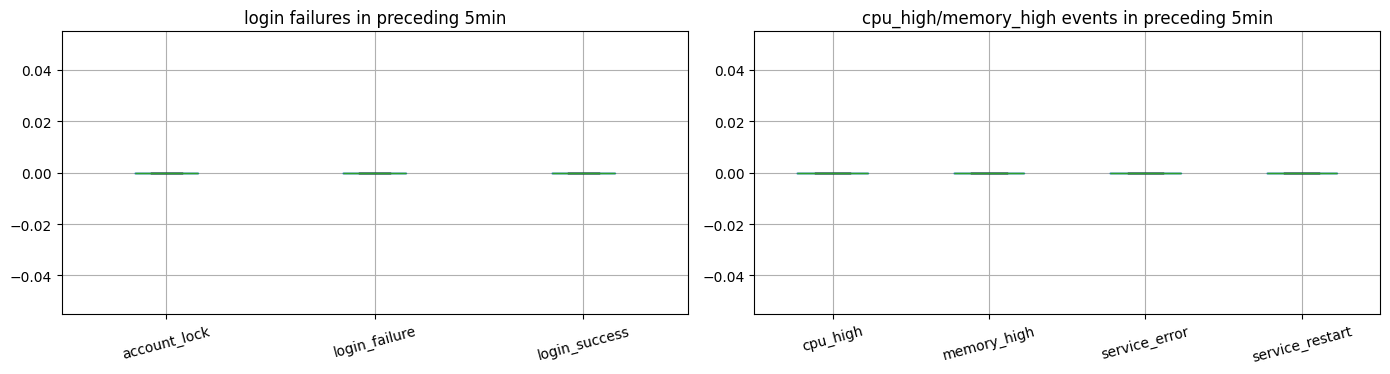

In [25]:
def time_windowed_event_count(df, target_events, window_minutes=5):
    """
    Count occurrences of target_events in the preceding time window
    for each row, grouped by device. Handles duplicate timestamps safely.
    """
    if isinstance(target_events, str):
        target_events = [target_events]

    df = df.sort_values(["device", "timestamp"]).reset_index(drop=True)
    counts = np.zeros(len(df), dtype=np.float32)
    window_sec = window_minutes * 60

    for dev, grp in df.groupby("device"):
        idx    = grp.index.values
        times  = grp["timestamp"].astype(np.int64).values // 10**9  # unix seconds
        events = grp["event_type"].values

        for i, row_idx in enumerate(idx):
            mask = (
                (times >= times[i] - window_sec) &
                (times <  times[i])               # exclude current event
            )
            counts[row_idx] = np.isin(events[mask], target_events).sum()

    return counts


# ── Compute time-windowed causal features ─────────────────────────────────────
print("Computing login_fail_last_5min ...")
df["login_fail_last_5min"] = time_windowed_event_count(
    df, "login_failure", window_minutes=5
)

print("Computing prior_cpu_or_mem_5min ...")
df["prior_cpu_or_mem_5min"] = time_windowed_event_count(
    df, ["cpu_high", "memory_high"], window_minutes=5
)

print("Done.\n")

# ── Re-check causality ratios with corrected features ─────────────────────────
print("=== Corrected Causality Ratios ===\n")

checks = [
    ("account_lock",  "login_fail_last_5min",   "login_failure → account_lock",  3.0),
    ("service_error", "prior_cpu_or_mem_5min",  "cpu/mem → service_error",       1.8),
    ("bandwidth_spike","prior_config_change",   "config_change → bandwidth_spike",2.0),
]

for event, feature, label, target in checks:
    event_mean  = df[df["event_type"] == event][feature].mean()
    global_mean = df[feature].mean()
    ratio       = event_mean / global_mean if global_mean > 0 else 0
    status      = "✓ PASS" if ratio >= target else "✗ BELOW TARGET"
    print(f"  {label}")
    print(f"    Event mean  : {event_mean:.4f}")
    print(f"    Global mean : {global_mean:.4f}")
    print(f"    Ratio       : {ratio:.2f}x  |  Target: {target:.1f}x  |  {status}\n")

# ── Distribution of new features per event type ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# login_fail_last_5min — focus on login_failure and account_lock
events_of_interest = ["login_failure", "account_lock", "login_success"]
subset = df[df["event_type"].isin(events_of_interest)]
subset.boxplot(column="login_fail_last_5min", by="event_type",
               ax=axes[0], sym="")
axes[0].set_title("login failures in preceding 5min")
axes[0].set_xlabel("")
plt.sca(axes[0]); plt.xticks(rotation=15)

# prior_cpu_or_mem_5min — focus on resource and service events
events_of_interest2 = ["cpu_high", "memory_high", "service_error", "service_restart"]
subset2 = df[df["event_type"].isin(events_of_interest2)]
subset2.boxplot(column="prior_cpu_or_mem_5min", by="event_type",
                ax=axes[1], sym="")
axes[1].set_title("cpu_high/memory_high events in preceding 5min")
axes[1].set_xlabel("")
plt.sca(axes[1]); plt.xticks(rotation=15)

plt.suptitle("")
plt.tight_layout()
plt.show()

=== Positional Causality Ratios ===

  login_failure → account_lock
    Event mean: 0.2832 | Global mean: 0.3024 | Ratio: 0.94x | ✗ BELOW TARGET

  cpu/mem → service_error
    Event mean: 0.5673 | Global mean: 0.5443 | Ratio: 1.04x | ✗ BELOW TARGET

  config_change → bandwidth_spike
    Event mean: 0.1924 | Global mean: 0.1880 | Ratio: 1.02x | ✗ BELOW TARGET



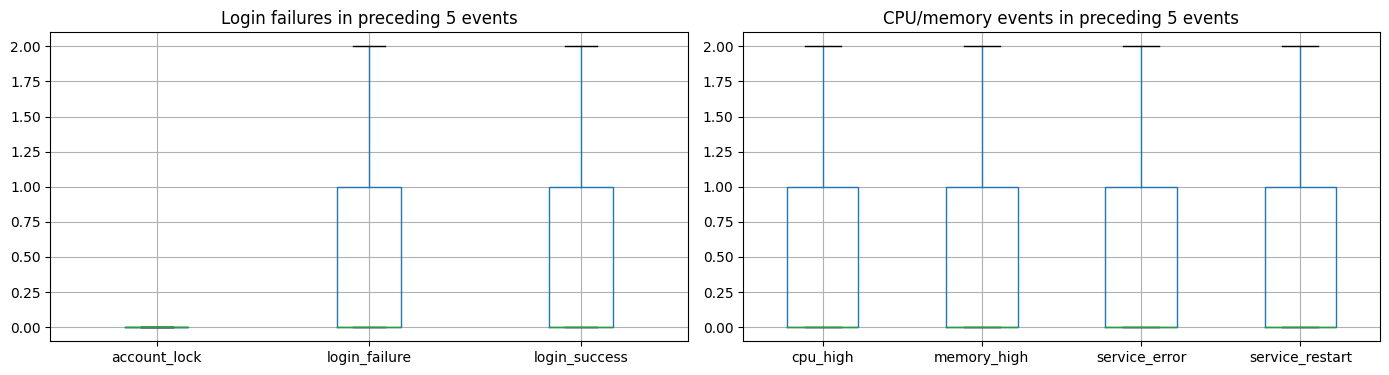

In [26]:
def positional_event_count(df, target_events, lookback=5):
    """Count target_events in the N events preceding each row, per device."""
    if isinstance(target_events, str):
        target_events = [target_events]

    df = df.sort_values(["device","timestamp"]).reset_index(drop=True)
    counts = np.zeros(len(df), dtype=np.float32)

    for dev, grp in df.groupby("device"):
        idx    = grp.index.values
        events = grp["event_type"].values
        for i in range(len(idx)):
            window = events[max(0, i-lookback):i]
            counts[idx[i]] = np.isin(window, target_events).sum()

    return counts

df["login_fail_prev5"]     = positional_event_count(df, "login_failure",          lookback=5)
df["cpu_mem_prev5"]        = positional_event_count(df, ["cpu_high","memory_high"],lookback=5)
df["config_change_prev5"]  = positional_event_count(df, "config_change",           lookback=5)

# Re-check
print("=== Positional Causality Ratios ===\n")
checks = [
    ("account_lock",   "login_fail_prev5",    "login_failure → account_lock",   3.0),
    ("service_error",  "cpu_mem_prev5",       "cpu/mem → service_error",        1.8),
    ("bandwidth_spike","config_change_prev5", "config_change → bandwidth_spike",2.0),
]
for event, feature, label, target in checks:
    em  = df[df["event_type"]==event][feature].mean()
    gm  = df[feature].mean()
    r   = em / gm if gm > 0 else 0
    s   = "✓ PASS" if r >= target else "✗ BELOW TARGET"
    print(f"  {label}")
    print(f"    Event mean: {em:.4f} | Global mean: {gm:.4f} | Ratio: {r:.2f}x | {s}\n")

# Visualise with positional features
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df[df["event_type"].isin(["login_failure","account_lock","login_success"])] \
    .boxplot(column="login_fail_prev5", by="event_type", ax=axes[0], sym="")
axes[0].set_title("Login failures in preceding 5 events")
axes[0].set_xlabel("")

df[df["event_type"].isin(["cpu_high","memory_high","service_error","service_restart"])] \
    .boxplot(column="cpu_mem_prev5", by="event_type", ax=axes[1], sym="")
axes[1].set_title("CPU/memory events in preceding 5 events")
axes[1].set_xlabel("")

plt.suptitle(""); plt.tight_layout(); plt.show()